# EY Water Quality Challenge EDA

This notebook explores the merged training dataset, target distributions, missingness, geographic coverage, and a few feature-target relationships.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from data_loading import build_model_tables
from features import TARGETS, add_features

sns.set_theme(style='whitegrid')

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
train_full, test_full = build_model_tables()
train_df = add_features(train_full)

print(train_df.shape)
train_df.head()

(9319, 22)


,Latitude,Longitude,Sample Date,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus,nir,green,swir16,swir22,...,pet,month,dayofyear,quarter,month_sin,month_cos,NDWI_green,NDWI_swir,landsat_missing,pet_log
0,-28.760833,17.730278,2011-01-02,128.912,555.0,10.0,11190.0,11426.0,7687.5,7645.0,...,174.2,1,2,1,0.5,0.866025,0.010435,0.185538,0,5.165928
1,-26.861111,28.884722,2011-01-03,74.720,162.9,163.0,17658.5,9550.0,13746.5,10574.0,...,124.1,1,3,1,0.5,0.866025,-0.298013,0.124566,0,4.829113
2,-26.450000,28.085833,2011-01-03,89.254,573.0,80.0,15210.0,10720.0,17974.0,14201.0,...,127.5,1,3,1,0.5,0.866025,-0.173159,-0.083293,0,4.855929
3,-27.671111,27.236944,2011-01-03,82.000,203.6,101.0,14887.0,10943.0,13522.0,11403.0,...,129.7,1,3,1,0.5,0.866025,-0.152691,0.048048,0,4.872905
4,-27.356667,27.286389,2011-01-03,56.100,145.1,151.0,16828.5,9502.5,12665.5,9643.0,...,129.2,1,3,1,0.5,0.866025,-0.278227,0.141147,0,4.869072


## Missingness overview

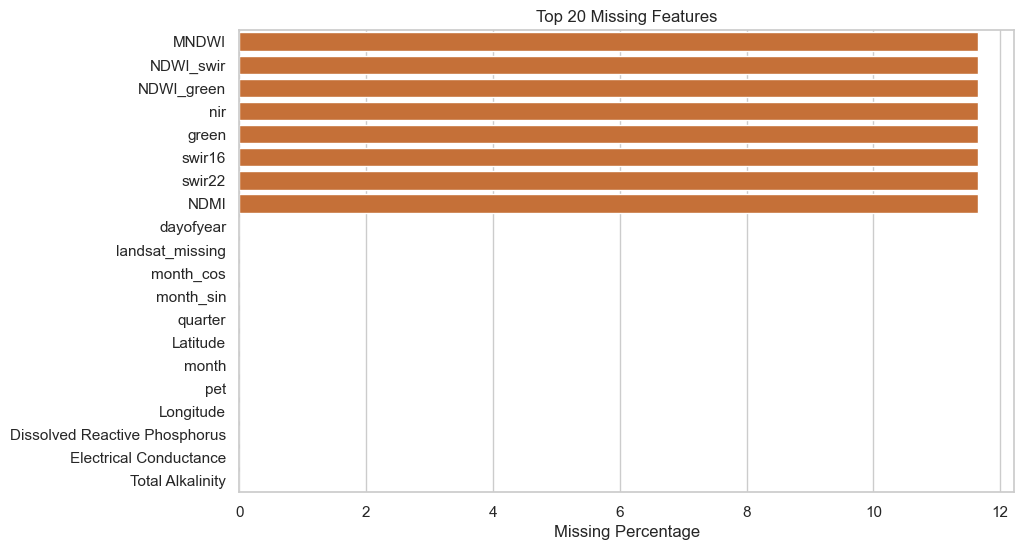

In [3]:
missing_pct = train_df.isna().mean().sort_values(ascending=False).head(20) * 100
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_pct.values, y=missing_pct.index, color='#dd6b20')
plt.title('Top 20 Missing Features')
plt.xlabel('Missing Percentage')
plt.ylabel('')
plt.show()

## Target distributions

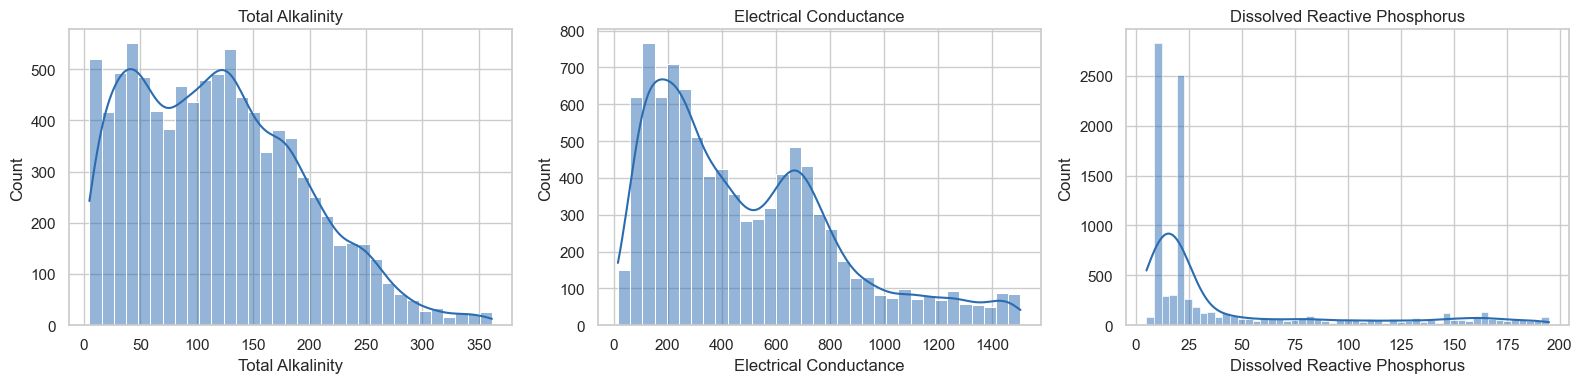

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, target in zip(axes, TARGETS):
    sns.histplot(train_df[target], kde=True, ax=ax, color='#2b6cb0')
    ax.set_title(target)
plt.tight_layout()
plt.show()

## Geographic sampling pattern

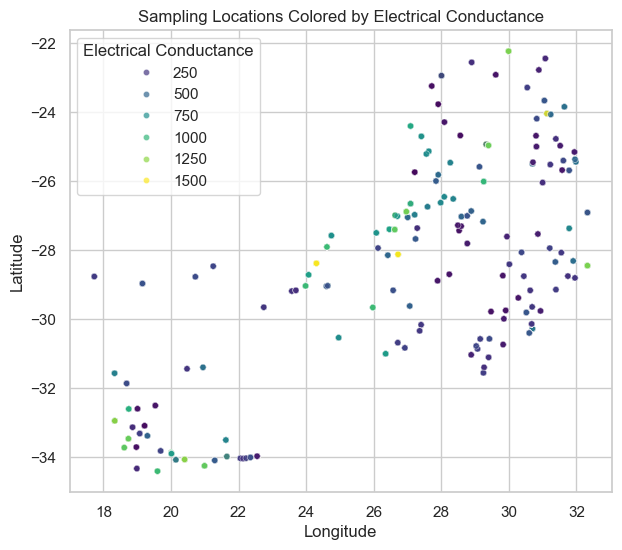

In [5]:
plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=train_df,
    x='Longitude',
    y='Latitude',
    hue='Electrical Conductance',
    palette='viridis',
    s=20,
    alpha=0.7,
)
plt.title('Sampling Locations Colored by Electrical Conductance')
plt.show()

## Correlation heatmap

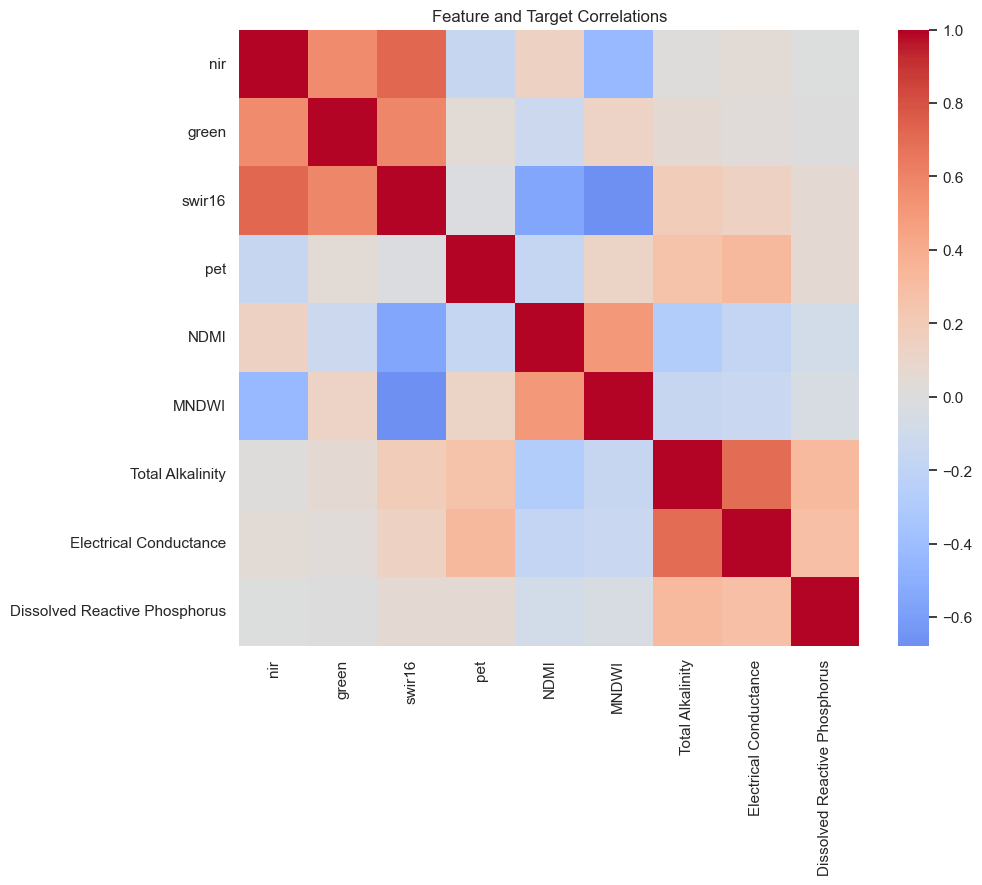

In [6]:
corr_cols = [col for col in ['nir', 'green', 'swir16', 'pet', 'NDMI', 'MNDWI'] if col in train_df.columns]
corr = train_df[corr_cols + TARGETS].corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Feature and Target Correlations')
plt.show()

## Quick feature-target diagnostics

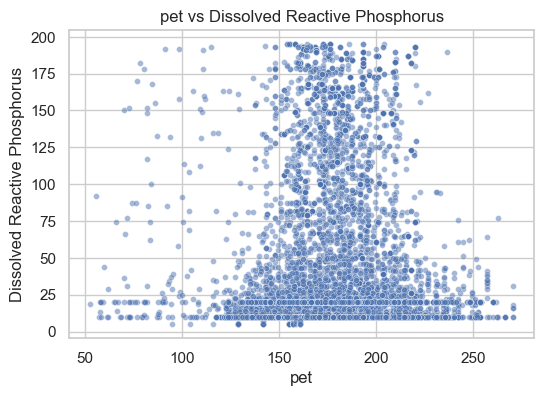

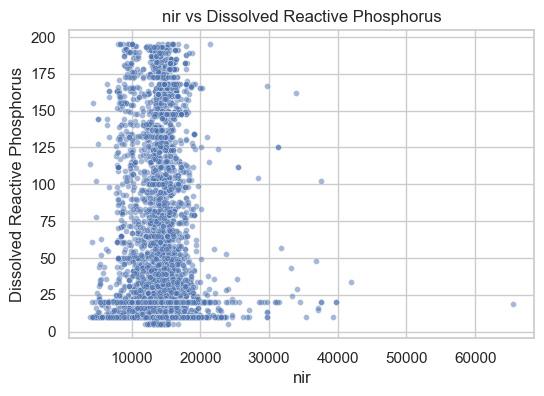

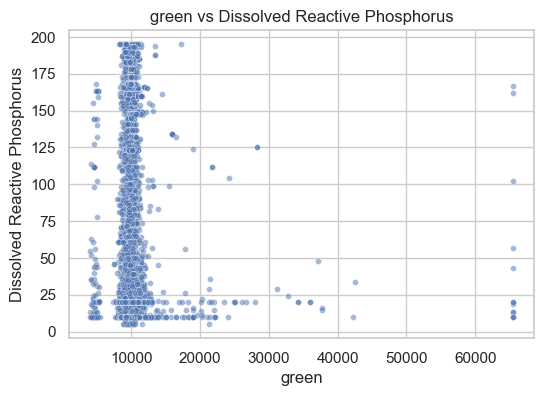

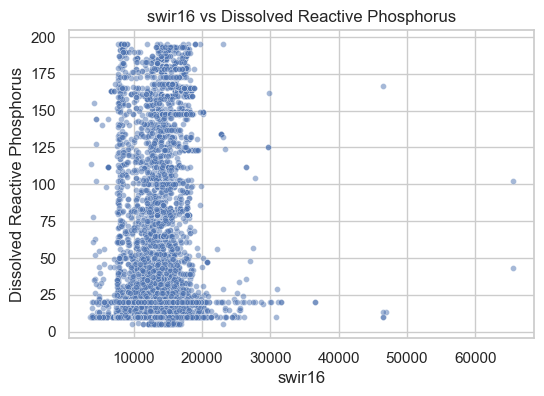

In [7]:
candidate_features = [feature for feature in ['pet', 'nir', 'green', 'swir16', 'NDWI_green', 'NDWI_swir'] if feature in train_df.columns]
for feature in candidate_features[:4]:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=train_df, x=feature, y='Dissolved Reactive Phosphorus', alpha=0.5, s=18)
    plt.title(f'{feature} vs Dissolved Reactive Phosphorus')
    plt.show()